# Support vector machines

Four course colabs merged: linear SVM on iris, non-linear SVM on iris, the `C`/`gamma` demo on synthetic
data, and SVMs on MNIST.

1. the idea: maximum margin, support vectors, soft margin
2. linear SVM on iris, binary then multiclass
3. kernels and the effect of `C` and `gamma`
4. non-linear SVM on iris
5. MNIST

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris, make_classification, make_circles, fetch_openml
from sklearn.metrics import (ConfusionMatrixDisplay, classification_report, RocCurveDisplay,
                             roc_auc_score, accuracy_score)
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedShuffleSplit
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.svm import SVC, LinearSVC

sns.set_theme(style="whitegrid")

## The idea

For two classes that can be separated by a line (a hyperplane in more dimensions), there are infinitely
many lines that do it. An SVM picks the one with the **largest margin**: the widest gap between the line
and the closest points of each class. Those closest points are the **support vectors**, and the solution
depends only on them.

Real data usually isn't perfectly separable, so the **soft margin** version allows some points inside the
margin or on the wrong side, at a cost. `C` sets that cost:

* **large `C`**: mistakes are expensive, narrow margin, fits the training data closely (can overfit)
* **small `C`**: mistakes are cheap, wide margin, smoother boundary (can underfit)

Equivalently, it minimises the hinge loss plus an L2 penalty:
$\frac{1}{2}\|\mathbf{w}\|^2 + C \sum_i \max(0, 1 - y_i(\mathbf{w}^T\mathbf{x}_i + b))$.

## Iris

| feature | |
|---|---|
| sepal length, sepal width, petal length, petal width | cm |
| class | setosa, versicolor, virginica (50 each) |

In [2]:
col_name = ["sepal_length_in_cm", "sepal_width_in_cm", "petal_length_in_cm", "petal_width_in_cm", "class"]
df = pd.read_csv("https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data",
                 header=None, names=col_name)
df.head()

,sepal_length_in_cm,sepal_width_in_cm,petal_length_in_cm,petal_width_in_cm,class
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


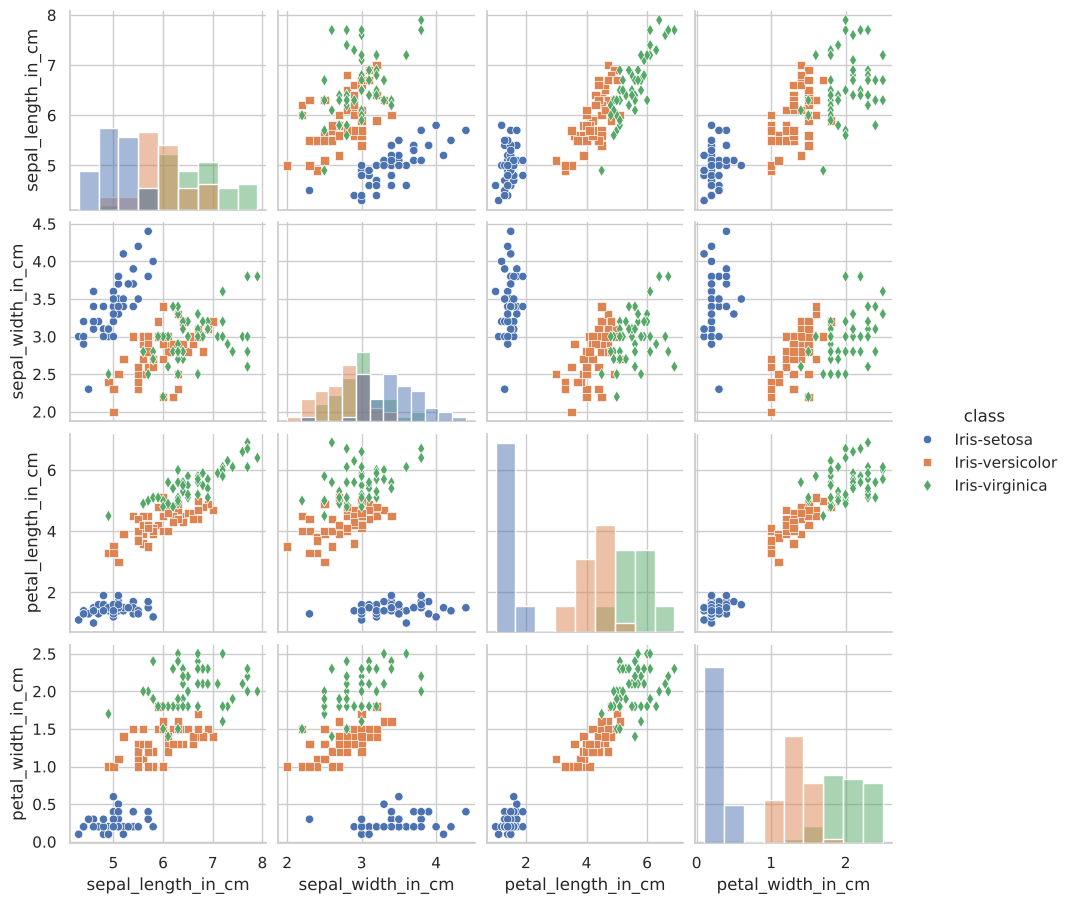

In [3]:
sns.pairplot(df, height=2.3, hue="class", diag_kind="hist", markers=["o", "s", "d"])
plt.show()

Setosa is far away from the other two on every petal measurement. Versicolor and virginica overlap.

## Binary, linearly separable: setosa vs versicolor

In [4]:
data = df[df["class"] != "Iris-virginica"].copy()
data["class"] = data["class"].map({"Iris-setosa": 1, "Iris-versicolor": -1})

X = data.drop(columns="class")
y = data["class"].to_numpy()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)
print("train:", X_train.shape, " test:", X_test.shape)

train: (75, 4)  test: (25, 4)


In [5]:
pipe_1 = Pipeline([('scaler', MinMaxScaler()), ("classifier", LinearSVC(C=1))])
pipe_1.fit(X_train, y_train)

acc = cross_val_score(pipe_1, X_train, y_train, cv=10)
print(f"CV accuracy: {acc.mean() * 100:.2f}%")

CV accuracy: 100.00%


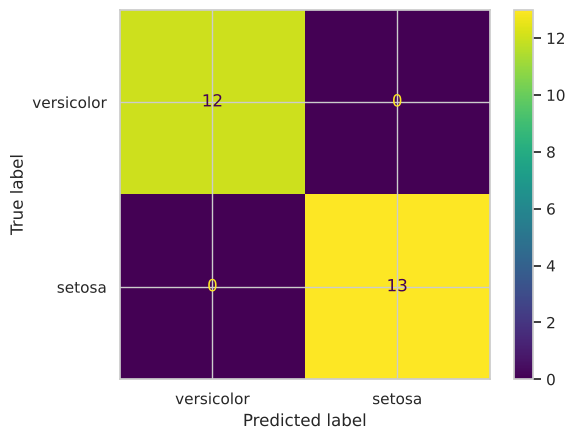

              precision    recall  f1-score   support

          -1       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        13

    accuracy                           1.00        25
   macro avg       1.00      1.00      1.00        25
weighted avg       1.00      1.00      1.00        25



In [6]:
y_pred = pipe_1.predict(X_test)
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=["versicolor", "setosa"])
plt.show()
print(classification_report(y_test, y_pred))

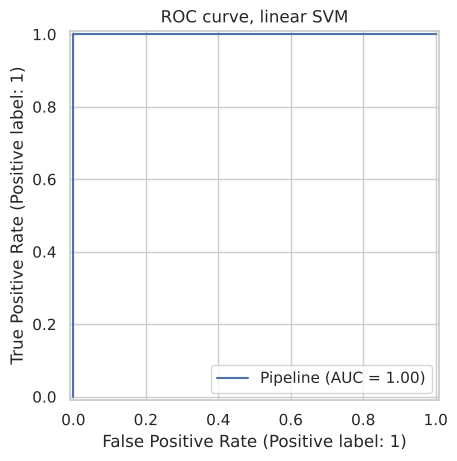

AUC: 1.0


In [7]:
RocCurveDisplay.from_estimator(pipe_1, X_test, y_test)
plt.title("ROC curve, linear SVM")
plt.show()
print("AUC:", roc_auc_score(y_test, pipe_1.decision_function(X_test)))

Perfect, as expected for two classes that don't overlap at all. (`plot_roc_curve` from the course was
removed in sklearn 1.2, `RocCurveDisplay` replaces it. The course also computed the AUC from the predicted
labels, it should use the continuous scores from `decision_function`. Here it's 1.0 either way.)

### Accuracy vs C

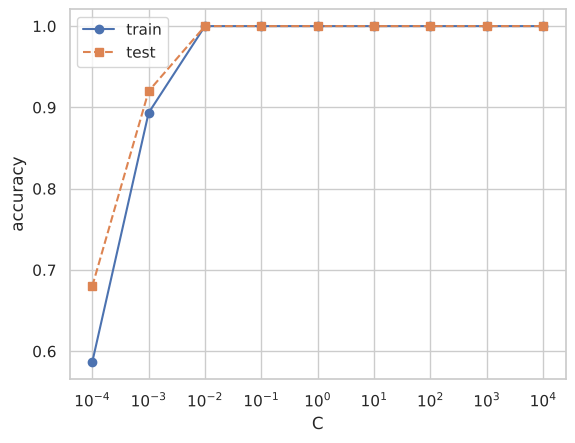

In [8]:
C_values = [0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000, 10000]
acc_tr, acc_te = [], []
for c in C_values:
    svm = make_pipeline(MinMaxScaler(), LinearSVC(C=c)).fit(X_train, y_train)
    acc_tr.append(svm.score(X_train, y_train))
    acc_te.append(svm.score(X_test, y_test))

plt.semilogx(C_values, acc_tr, 'o-', label='train')
plt.semilogx(C_values, acc_te, 's--', label='test')
plt.xlabel('C'); plt.ylabel('accuracy'); plt.legend()
plt.show()

With tiny `C` the penalty on the weights dominates, the weights shrink to almost nothing and the model
predicts one class for everything (about 50%). Once `C` is around 0.1 or more it separates perfectly.

### Decision boundary and support vectors

Two features (sepal length and width) so it can be drawn. Solid line: decision boundary. Dashed lines:
the margins. Circled points: support vectors.

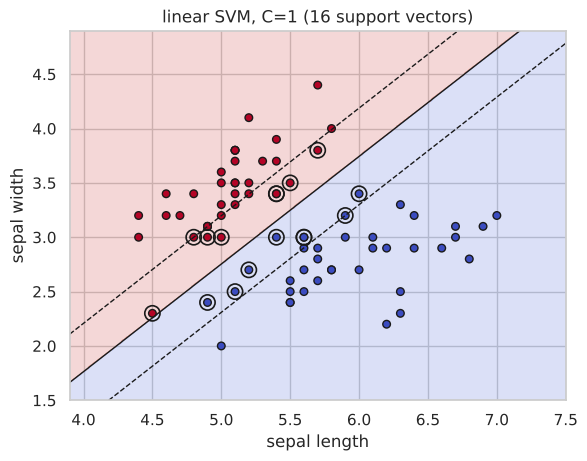

In [9]:
def plot_svm(model, X, y, ax=None, title="", show_margin=True):
    ax = ax or plt.gca()
    xx, yy = np.meshgrid(np.linspace(X[:, 0].min() - 0.5, X[:, 0].max() + 0.5, 300),
                         np.linspace(X[:, 1].min() - 0.5, X[:, 1].max() + 0.5, 300))
    grid = np.c_[xx.ravel(), yy.ravel()]
    ax.contourf(xx, yy, model.predict(grid).reshape(xx.shape), alpha=0.2, cmap='coolwarm')
    if show_margin and hasattr(model, "decision_function") and len(np.unique(y)) == 2:
        z = model.decision_function(grid).reshape(xx.shape)
        ax.contour(xx, yy, z, levels=[-1, 0, 1], colors='k', linestyles=['--', '-', '--'], linewidths=1)
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolor='k', s=30)
    if hasattr(model, "support_vectors_"):
        sv = model.support_vectors_
        ax.scatter(sv[:, 0], sv[:, 1], s=120, facecolors='none', edgecolors='k', linewidths=1.2)
    ax.set_title(title)

X2 = X_train.to_numpy()[:, :2]
svc = SVC(kernel='linear', C=1).fit(X2, y_train)
plot_svm(svc, X2, y_train, title=f"linear SVM, C=1 ({len(svc.support_vectors_)} support vectors)")
plt.xlabel('sepal length'); plt.ylabel('sepal width')
plt.show()

Only the circled points determine where the line goes. Moving any other point (without crossing the
margin) wouldn't change the model.

## Multiclass with the two sepal features

Using only sepal length and width makes the problem harder, because versicolor and virginica overlap there.

In [10]:
iris = load_iris()
X = iris.data[:, :2]
y = iris.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

pipe_2 = Pipeline([('scaler', MinMaxScaler()), ("classifier", SVC(kernel='linear', C=1))])
pipe_2.fit(X_train, y_train)
y_pred = pipe_2.predict(X_test)
print(classification_report(y_test, y_pred, target_names=iris.target_names))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.78      0.64      0.70        11
   virginica       0.71      0.83      0.77        12

    accuracy                           0.84        38
   macro avg       0.83      0.82      0.82        38
weighted avg       0.85      0.84      0.84        38



In [11]:
acc = cross_val_score(pipe_2, X_train, y_train, cv=10)
print(acc.round(2))
print(f"CV accuracy: {acc.mean() * 100:.2f}%")

[0.67 0.92 0.73 0.82 0.64 1.   0.73 0.82 0.82 0.64]
CV accuracy: 77.65%


(The course printed precision as `"{:.2f} %".format(0.84)`, i.e. "0.84 %". Also with micro averaging,
precision, recall and F1 are all equal to accuracy for single-label problems.)

`SVC` handles multiclass with **one-vs-one**: one classifier per pair of classes (3 here), and the class that
wins the most pairwise votes is predicted. `decision_function_shape='ovr'` (the default) only changes the
shape of the scores it returns, not how it's trained. `LinearSVC` uses one-vs-rest instead.

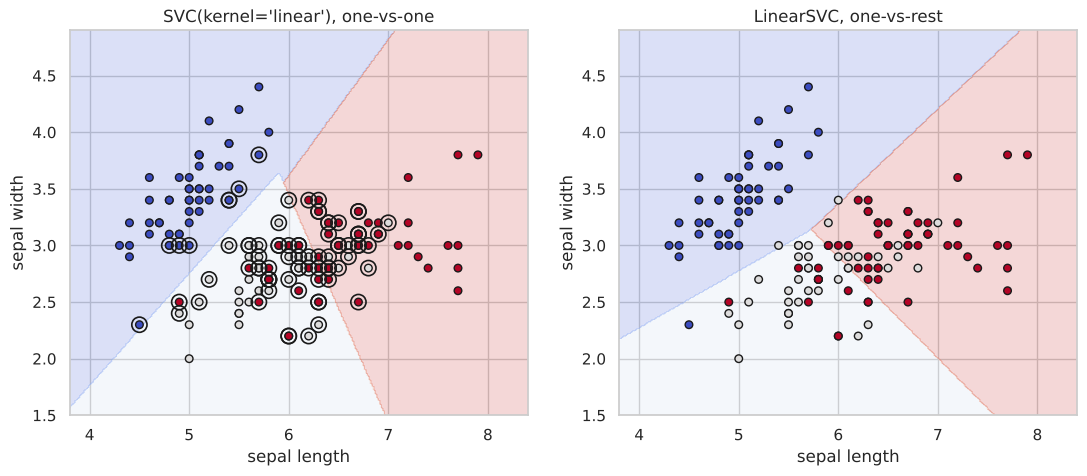

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
plot_svm(SVC(kernel='linear', C=1).fit(X, y), X, y, ax=axes[0], title="SVC(kernel='linear'), one-vs-one")
plot_svm(LinearSVC(C=1, max_iter=10000).fit(X, y), X, y, ax=axes[1], title="LinearSVC, one-vs-rest")
for ax in axes:
    ax.set_xlabel('sepal length'); ax.set_ylabel('sepal width')
plt.show()

Setosa (left) is separated cleanly. Versicolor and virginica overlap, and no straight line can split them
well with these two features. (`max_iter=100` in the course caused the convergence warning.)

Tuning `C`. The course used `RandomizedSearchCV` with only 4 candidate values, which just tries all of them
(and warns that `n_iter=10` is bigger than the grid). `GridSearchCV` is the natural choice there:

In [13]:
grid = GridSearchCV(make_pipeline(MinMaxScaler(), SVC(kernel='linear')), {'svc__C': [0.1, 1, 10, 100]}, cv=5)
grid.fit(X_train, y_train)
print("best:", grid.best_params_, f" CV accuracy {grid.best_score_:.3f}  test accuracy {grid.score(X_test, y_test):.3f}")

best: {'svc__C': 100}  CV accuracy 0.796  test accuracy 0.842


## Kernels

A linear boundary can't separate data like this:

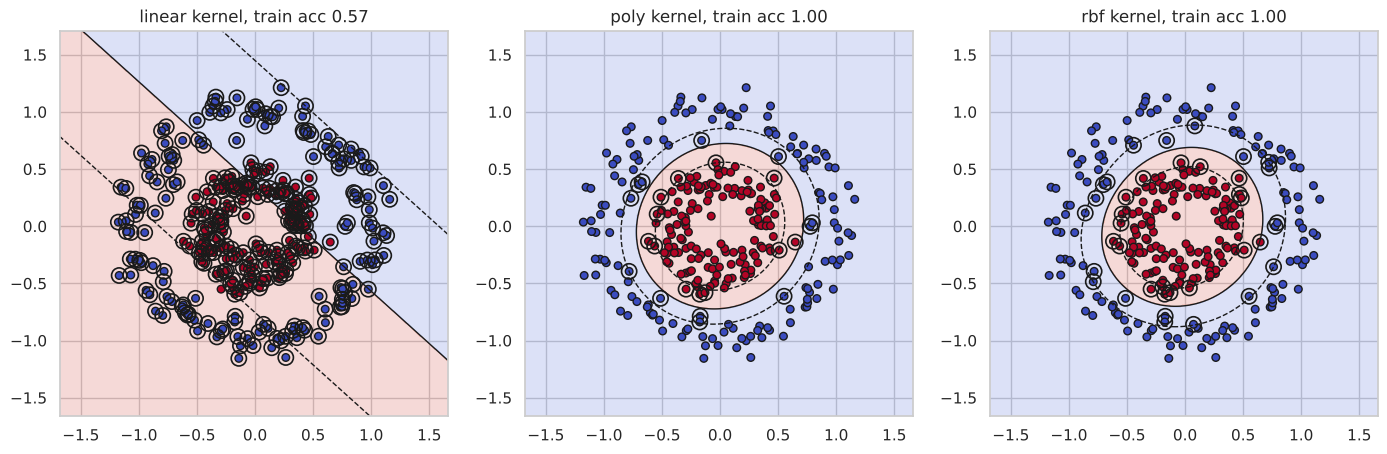

In [14]:
Xc, yc = make_circles(n_samples=300, factor=0.4, noise=0.1, random_state=0)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for ax, kernel in zip(axes, ['linear', 'poly', 'rbf']):
    model = SVC(kernel=kernel, degree=2, C=1).fit(Xc, yc)
    plot_svm(model, Xc, yc, ax=ax, title=f"{kernel} kernel, train acc {model.score(Xc, yc):.2f}")
plt.show()

The **kernel trick**: an SVM only ever uses dot products between points, $\mathbf{x}_i^T \mathbf{x}_j$.
Replacing that with a kernel function $K(\mathbf{x}_i, \mathbf{x}_j)$ is equivalent to mapping the
points into a higher-dimensional space and finding a linear boundary there, without ever computing the
mapping.

* polynomial: $K = (\gamma \, \mathbf{x}_i^T\mathbf{x}_j + r)^d$
* RBF (Gaussian): $K = \exp(-\gamma \|\mathbf{x}_i - \mathbf{x}_j\|^2)$, a similarity that's 1 for
  identical points and drops off with distance

For the circles, a degree-2 polynomial kernel is enough (the boundary is a circle, i.e. $x_1^2 + x_2^2 = r^2$).

### C and gamma for the RBF kernel

`gamma` controls how far each training point's influence reaches. Large `gamma` = only very close points
matter, so the boundary can wrap tightly around individual points. Small `gamma` = smooth, almost linear.

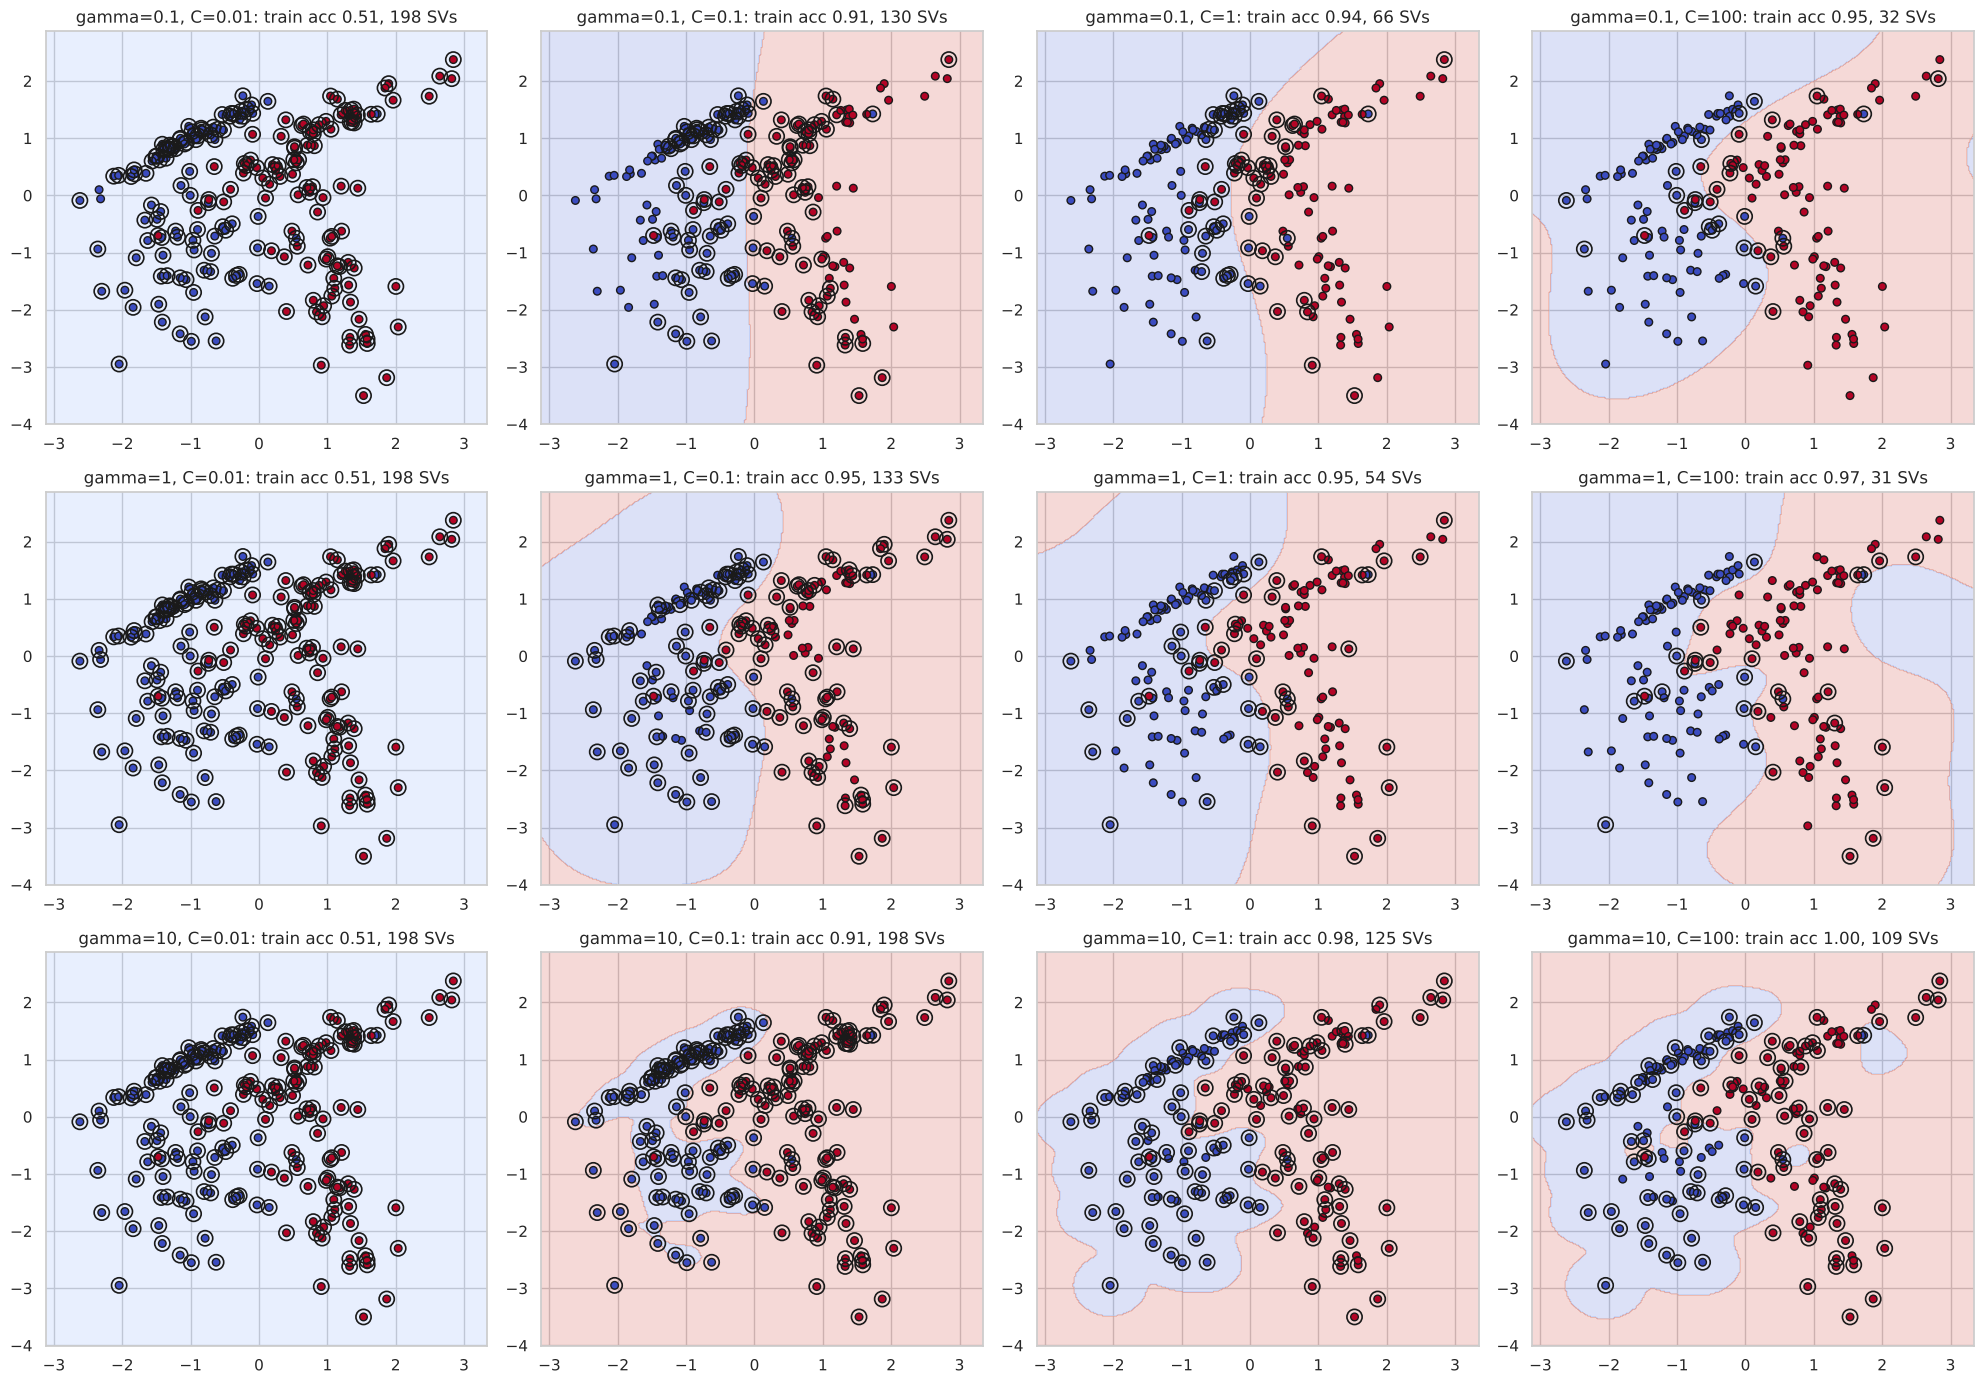

In [15]:
X, y = make_classification(n_samples=200, n_features=2, n_informative=2, n_redundant=0,
                           n_repeated=0, n_classes=2, random_state=44)

fig, axes = plt.subplots(3, 4, figsize=(20, 14))
for row, gamma in zip(axes, [0.1, 1, 10]):
    for ax, C in zip(row, [0.01, 0.1, 1, 100]):
        model = SVC(kernel='rbf', gamma=gamma, C=C).fit(X, y)
        plot_svm(model, X, y, ax=ax, show_margin=False,
                 title=f"gamma={gamma}, C={C}: train acc {model.score(X, y):.2f}, {len(model.support_)} SVs")
plt.tight_layout()
plt.show()

* **C = 0.01**: everything is predicted as one class (about 50% accuracy), and almost every point is a
  support vector. The penalty for misclassifying is too low to bother.
* **gamma = 10, C = 100**: little islands around individual points. Training accuracy is high, but that
  boundary won't generalise.
* **gamma = 0.1**: nearly linear boundary regardless of `C`.

The two have to be tuned together, usually with a grid search on a log scale.

## Non-linear SVM on iris: versicolor vs virginica

The pair that overlapped in the linear notebook.

In [16]:
data = df[df["class"] != "Iris-setosa"]
X = data.drop(columns="class")
y = (data["class"] == "Iris-virginica").astype(int).to_numpy()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)

pipe_rbf = Pipeline([('scaler', MinMaxScaler()), ("classifier", SVC(kernel='rbf', C=1))])
pipe_rbf.fit(X_train, y_train)
print(f"CV accuracy: {cross_val_score(pipe_rbf, X_train, y_train, cv=10).mean() * 100:.2f}%")
print(classification_report(y_test, pipe_rbf.predict(X_test), target_names=["versicolor", "virginica"]))

CV accuracy: 94.64%
              precision    recall  f1-score   support

  versicolor       1.00      0.85      0.92        13
   virginica       0.86      1.00      0.92        12

    accuracy                           0.92        25
   macro avg       0.93      0.92      0.92        25
weighted avg       0.93      0.92      0.92        25



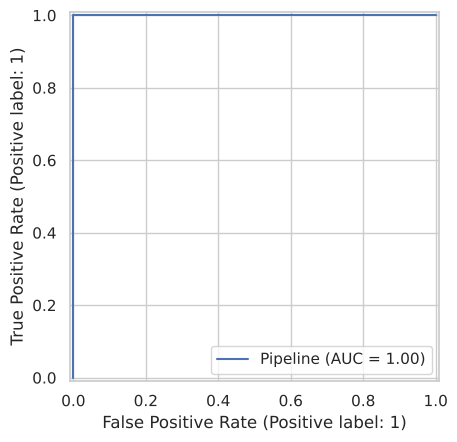

AUC from scores: 1.0
AUC from labels (what the course computed): 0.923


In [17]:
RocCurveDisplay.from_estimator(pipe_rbf, X_test, y_test)
plt.show()
print("AUC from scores:", round(roc_auc_score(y_test, pipe_rbf.decision_function(X_test)), 3))
print("AUC from labels (what the course computed):", round(roc_auc_score(y_test, pipe_rbf.predict(X_test)), 3))

Here the difference matters: computing AUC from hard labels gives a lower number, because it throws
away the ranking information the ROC curve is built from.

### Grid search over C and gamma

The course scaled the training and test sets with two separate `fit_transform` calls, so the test data
was scaled with its own min/max. Putting the scaler in a pipeline avoids that.

In [18]:
C_range = np.logspace(-2, 10, 13)
gamma_range = np.logspace(-9, 3, 13)
cv = StratifiedShuffleSplit(n_splits=5, test_size=0.2, random_state=42)

grid = GridSearchCV(make_pipeline(StandardScaler(), SVC(kernel='rbf')),
                    param_grid={'svc__C': C_range, 'svc__gamma': gamma_range}, cv=cv, n_jobs=-1)
grid.fit(X_train, y_train)
print("best:", {k.split('__')[1]: v for k, v in grid.best_params_.items()}, f"CV accuracy {grid.best_score_:.2f}")

best: {'C': np.float64(100.0), 'gamma': np.float64(0.001)} CV accuracy 1.00


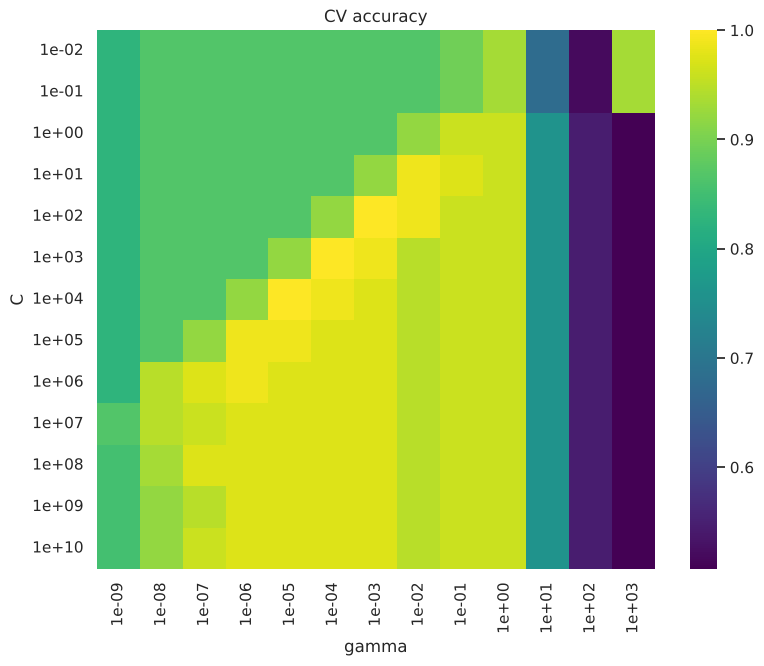

In [19]:
scores = grid.cv_results_['mean_test_score'].reshape(len(C_range), len(gamma_range))
plt.figure(figsize=(9, 7))
sns.heatmap(scores, xticklabels=[f"{g:.0e}" for g in gamma_range], yticklabels=[f"{c:.0e}" for c in C_range],
            cmap='viridis', annot=False)
plt.xlabel('gamma'); plt.ylabel('C'); plt.title('CV accuracy')
plt.show()

The good region is a diagonal band: smaller `gamma` needs larger `C` to compensate. Too large a `gamma`
(right side) fails for any `C`. The best score is 1.0 on 5 validation splits of 15 points each, so many
settings tie.

In [20]:
print(f"test accuracy of the best model: {grid.score(X_test, y_test):.3f}")

test accuracy of the best model: 0.920


### RBF vs polynomial boundaries on two features

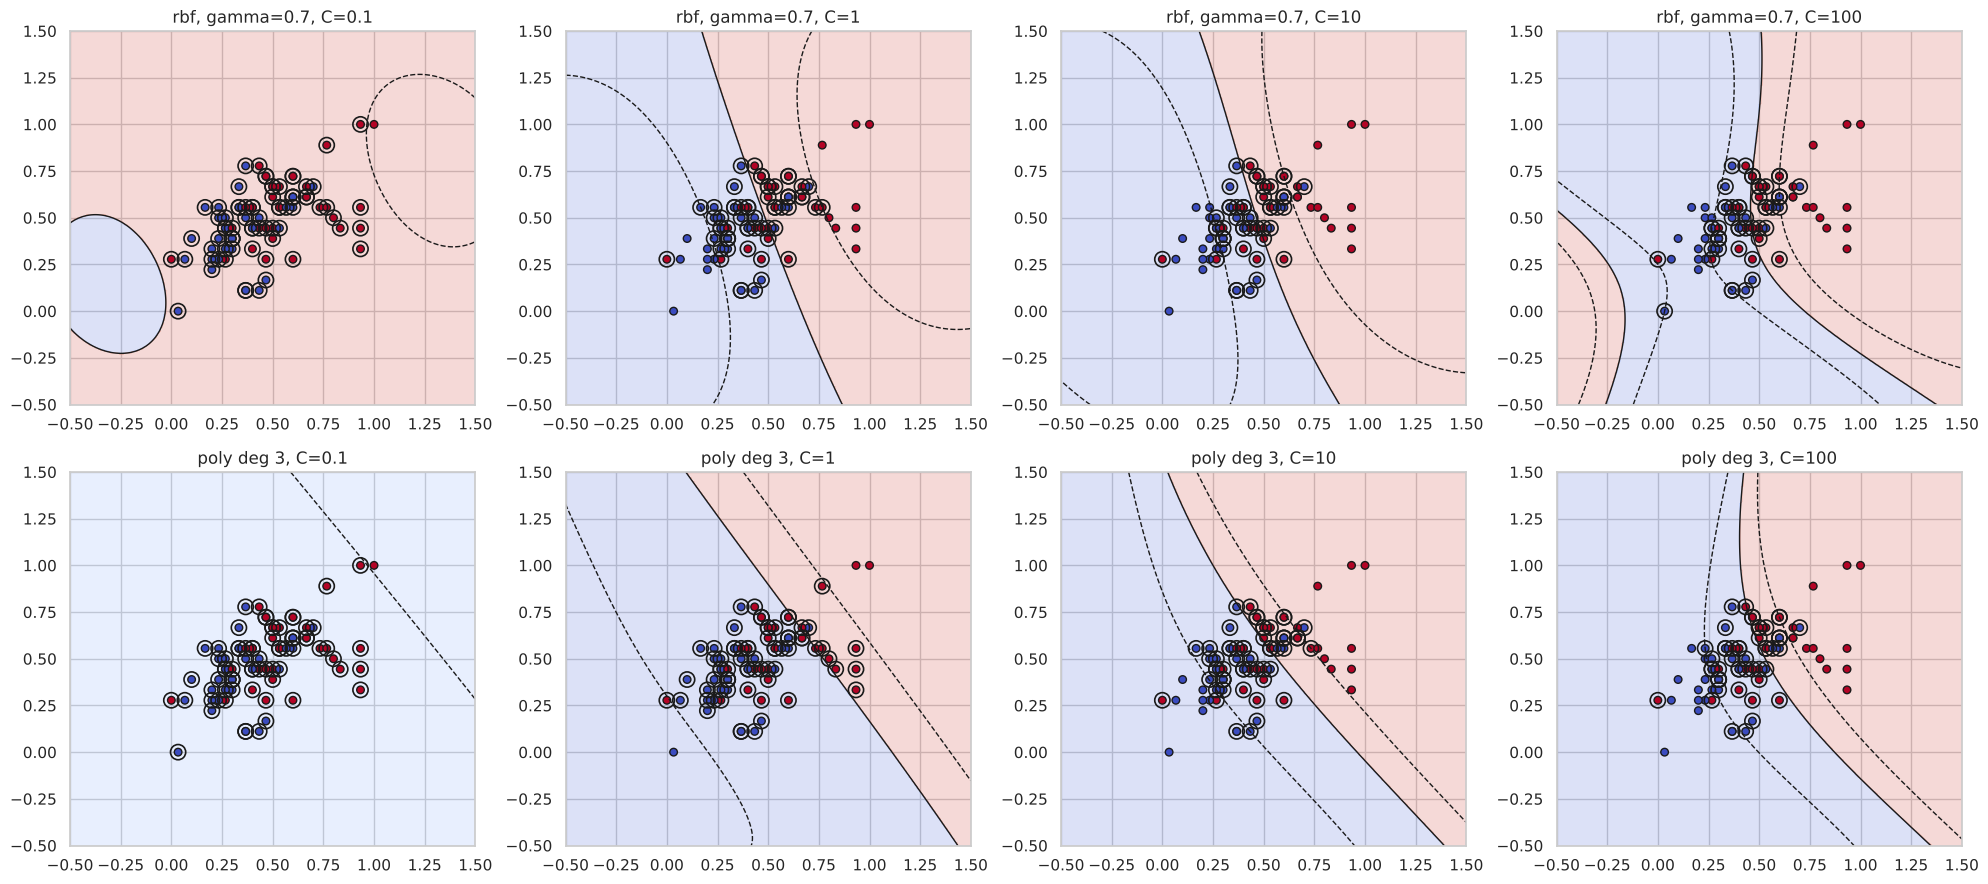

In [21]:
X2 = MinMaxScaler().fit_transform(X_train.to_numpy()[:, :2])
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
for ax, c in zip(axes[0], [0.1, 1, 10, 100]):
    plot_svm(SVC(kernel='rbf', gamma=0.7, C=c).fit(X2, y_train), X2, y_train, ax=ax, title=f"rbf, gamma=0.7, C={c}")
for ax, c in zip(axes[1], [0.1, 1, 10, 100]):
    plot_svm(SVC(kernel='poly', degree=3, gamma='auto', C=c).fit(X2, y_train), X2, y_train, ax=ax, title=f"poly deg 3, C={c}")
plt.tight_layout()
plt.show()

On sepal features alone, versicolor and virginica overlap heavily, so no kernel separates them well.
The petal features are the ones that make this pair separable, which is why the 4-feature model above does
much better.

## MNIST

The course loaded MNIST through Keras. `fetch_openml` gives the same data without needing TensorFlow. SVMs
scale badly with the number of samples (training is roughly quadratic or worse), so it uses the first
10,000 training images and 2,000 test images.

In [22]:
X, y = fetch_openml('mnist_784', version=1, return_X_y=True)
X, y = X.to_numpy() / 255, y.to_numpy()
X_train, y_train = X[:10000], y[:10000]
X_test, y_test = X[60000:62000], y[60000:62000]
print(X_train.shape, X_test.shape)

(10000, 784) (2000, 784)


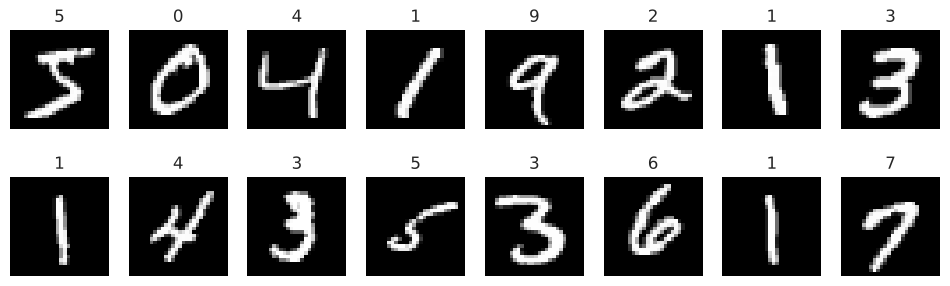

In [23]:
fig, axes = plt.subplots(2, 8, figsize=(12, 3.5))
for ax, img, label in zip(axes.ravel(), X_train, y_train):
    ax.imshow(img.reshape(28, 28), cmap='gray'); ax.set_title(label); ax.axis('off')
plt.show()

### Linear kernel

In [24]:
pipe_lin = Pipeline([('scaler', MinMaxScaler()), ("classifier", SVC(kernel='linear', C=1))])
pipe_lin.fit(X_train, y_train)
print(f"CV accuracy (2-fold): {cross_val_score(pipe_lin, X_train, y_train, cv=2).mean() * 100:.2f}%")
print(classification_report(y_test, pipe_lin.predict(X_test)))

CV accuracy (2-fold): 91.07%


              precision    recall  f1-score   support

           0       0.91      0.96      0.94       175
           1       0.96      0.99      0.98       234
           2       0.89      0.89      0.89       219
           3       0.85      0.88      0.86       207
           4       0.90      0.94      0.92       217
           5       0.89      0.85      0.87       179
           6       0.90      0.93      0.91       178
           7       0.89      0.87      0.88       205
           8       0.89      0.83      0.86       192
           9       0.89      0.84      0.86       194

    accuracy                           0.90      2000
   macro avg       0.90      0.90      0.90      2000
weighted avg       0.90      0.90      0.90      2000



### RBF kernel

In [25]:
for gamma in [0.1, 'scale']:
    pipe_rbf = Pipeline([('scaler', MinMaxScaler()), ("classifier", SVC(kernel='rbf', gamma=gamma, C=1))])
    pipe_rbf.fit(X_train, y_train)
    y_pred = pipe_rbf.predict(X_test)
    g = pipe_rbf[-1]._gamma
    print(f"gamma={gamma!s:6s} (= {g:.4f})  test accuracy {accuracy_score(y_test, y_pred):.3f}")

gamma=0.1    (= 0.1000)  test accuracy 0.850


gamma=scale  (= 0.0134)  test accuracy 0.944


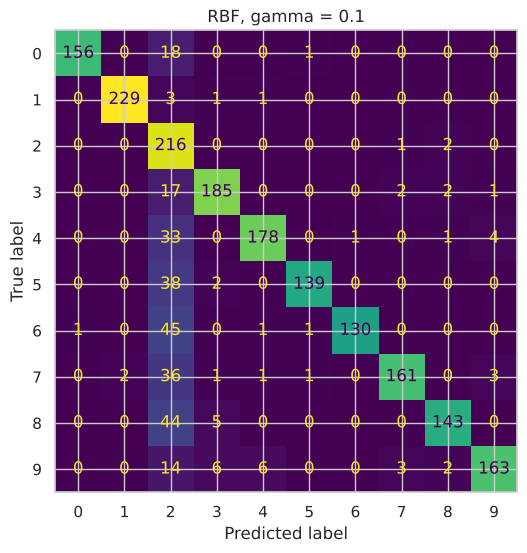

In [26]:
pipe_bad = Pipeline([('scaler', MinMaxScaler()), ("classifier", SVC(kernel='rbf', gamma=0.1, C=1))]).fit(X_train, y_train)
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay.from_predictions(y_test, pipe_bad.predict(X_test), ax=ax, colorbar=False)
ax.set_title("RBF, gamma = 0.1")
plt.show()

The course used `gamma=0.1` and got 85%, worse than the linear kernel, with a strange pattern: almost
every misclassified image was predicted as "2" (precision for 2 was 0.47). With 784 features, squared
distances between images are large (around 50-100), so `exp(-0.1 * distance)` is practically 0 for every
pair of different images. Each training point only "sees" itself, and test images that aren't close to
anything fall back to whichever class wins by default.

`gamma='scale'` (the default) sets it to `1 / (n_features * X.var())`, about 0.013 here, which gives about 94%.

### Grid search

On 5,000 images with 3 folds, to keep it quick. The course's grid used `np.logspace(-2, 10, 3)` for both
`C` and `gamma`, which gives just three very far apart values (gamma = 1e-9, 1e-3, 1e3).

In [27]:
grid = GridSearchCV(make_pipeline(MinMaxScaler(), SVC(kernel='rbf')),
                    param_grid={'svc__C': [1, 10, 100], 'svc__gamma': [0.001, 0.01, 0.05]},
                    cv=StratifiedShuffleSplit(n_splits=3, test_size=0.2, random_state=42), n_jobs=-1)
grid.fit(X_train[:5000], y_train[:5000])

res = pd.DataFrame(grid.cv_results_)
res.pivot_table(index='param_svc__C', columns='param_svc__gamma', values='mean_test_score').round(3)

param_svc__gamma,0.001,0.010,0.050
param_svc__C,,,
1,0.913,0.952,0.958
10,0.936,0.960,0.958
100,0.936,0.960,0.958


In [28]:
best = grid.best_estimator_.fit(X_train, y_train)
print("best:", grid.best_params_)
print(f"test accuracy, trained on 10,000 images: {best.score(X_test, y_test):.3f}")

best: {'svc__C': 10, 'svc__gamma': 0.01}


test accuracy, trained on 10,000 images: 0.955


About 95.5%, better than every linear model on MNIST (about 92%), with only a sixth of the training data.

## Summary

* SVMs find the maximum margin boundary, and only the support vectors define it
* `C` trades margin width against training errors
* kernels give non-linear boundaries without explicitly creating new features. RBF is the default choice,
  and `gamma` controls how local each point's influence is
* scale the features, and tune `C` and `gamma` together on a log grid
* training time grows fast with the number of samples, so SVMs are best for small to medium datasets